In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ryanbadai/clothes-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.37G/1.37G [01:07<00:00, 21.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1):
['Clothes_Dataset']


In [ ]:
import os

# Explore the structure inside 'Clothes_Dataset'
clothes_path = os.path.join(path, 'Clothes_Dataset')
if os.path.exists(clothes_path):
    print(f"Subdirectories in Clothes_Dataset: {os.listdir(clothes_path)}")
else:
    print(f"Directory {clothes_path} does not exist. Please check the file structure.")

Subdirectories in Clothes_Dataset: ['Celana_Panjang', 'Gaun', 'Jaket_Denim', 'Celana_Pendek', 'Rok', 'Blazer', 'Jaket_Olahraga', 'Kaos', 'Polo', 'Hoodie', 'Jeans', 'Sweter', 'Mantel', 'Kemeja', 'Jaket']


Found 7500 images. Displaying 6 sample images:


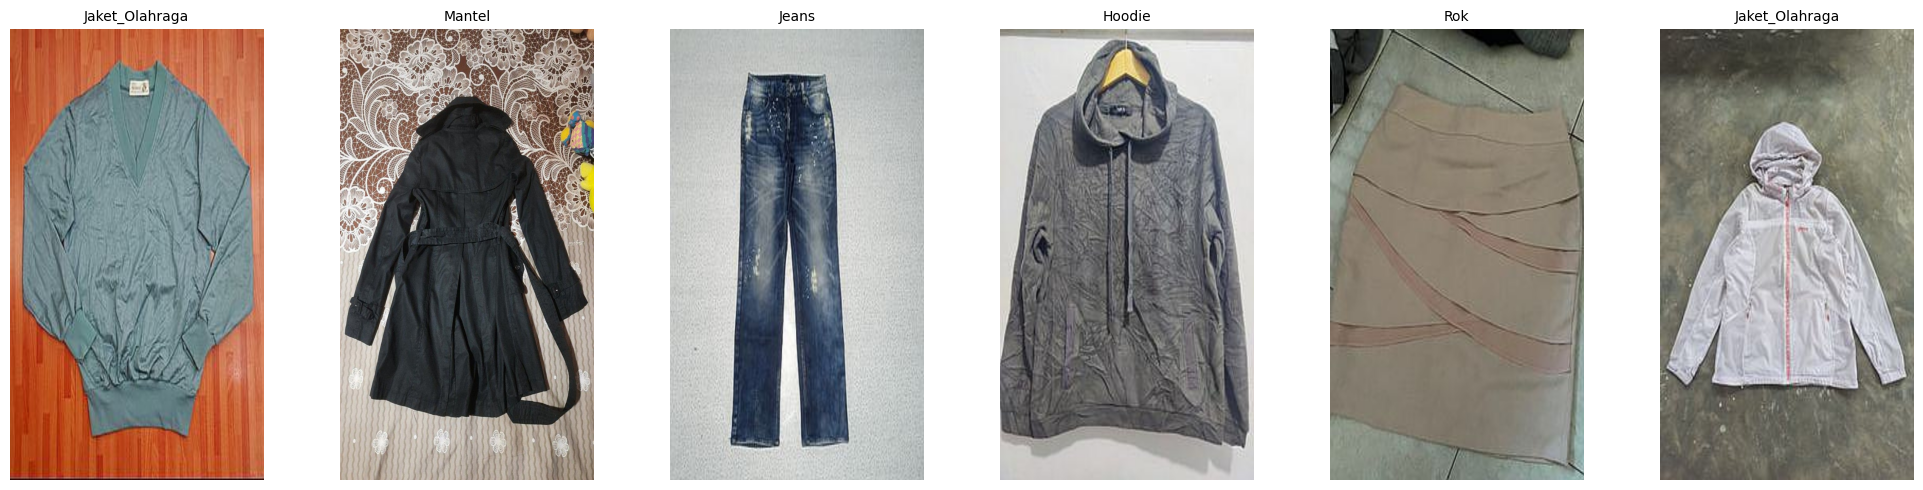

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the actual path of the clothes dataset
clothes_path = os.path.join(path, 'Clothes_Dataset')
display_sample_images(clothes_path)

In [ ]:
import os

# Define paths for the clothes dataset
input_folder = os.path.join(path, 'Clothes_Dataset')
output_folder = '/content/clothes_dataset_split'

if os.path.exists(input_folder):
    print(f"Preparing to split clothes data from: {input_folder}")
else:
    print(f"Error: {input_folder} not found.")

Preparing to split clothes data from: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1/Clothes_Dataset


In [ ]:
!pip install split-folders

In [ ]:
import os
try:
    import splitfolders
except ImportError:
    !pip install split-folders
    import splitfolders

# Split the clothes dataset: train=0.8, val(test)=0.2
# seed=42 for reproducibility
if os.path.exists(input_folder):
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Clothes dataset split successfully into: {output_folder}")

Copying files: 7500 files [00:09, 798.05 files/s]

Clothes dataset split successfully into: /content/clothes_dataset_split


In [ ]:
# Check the directory structure of the split clothes dataset
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 1: # Showing top level folders (train/val)
        print(f"{indent}{os.path.basename(root)}/")

clothes_dataset_split/
    train/
    val/


In [ ]:
import os

def count_files(directory):
    if not os.path.exists(directory):
        return 0
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"Clothes Dataset Statistics:")
if total > 0:
    print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%) -- Target: 80%")
    print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%) -- Target: 20%")
    print(f"- Total images: {total}")
else:
    print("No images found. Please ensure the split command in the previous cell executed successfully.")

Clothes Dataset Statistics:
- Train Set: 6000 images (80.0%) -- Target: 80%
- Test Set (val): 1500 images (20.0%) -- Target: 20%
- Total images: 7500


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Training will be slow on CPU.')
else:
    print(f'Found GPU at: {device_name}')

!nvidia-smi

Found GPU at: /device:GPU:0
Tue Aug 11 04:00:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     105MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers

# Data Preprocessing
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Model Building
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training (using small number of epochs for demonstration)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 6000 images belonging to 15 classes.
Found 1500 images belonging to 15 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.4457 - loss: 1.6889 - val_accuracy: 0.6447 - val_loss: 1.0842
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 175s 933ms/step - accuracy: 0.5680 - loss: 1.3085 - val_accuracy: 0.6520 - val_loss: 1.0042
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 176s 933ms/step - accuracy: 0.5958 - loss: 1.1950 - val_accuracy: 0.6867 - val_loss: 0.9409
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 179s 950ms/step - accuracy: 0.6273 - loss: 1.1399 - val_accuracy: 0.6927 - val_loss: 0.9426
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 181s 963ms/step - accuracy: 0.6350 - loss: 1.1007 - val_accuracy: 0.6893 - val_loss: 0.9296
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 179s 952ms/step - accuracy: 0.6468 - loss: 1.0855 - val_accuracy: 0.7040 - val_loss: 0.8666
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 175s 930ms/step - accuracy: 0.6557

In [ ]:
import pandas as pd

# Summarize results
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

# Display per-epoch history
history_df = pd.DataFrame(history.history)
display(history_df)

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 263ms/step - accuracy: 0.7213 - loss: 0.8255
Final Validation Loss: 0.8255
Final Validation Accuracy: 0.7213


,accuracy,loss,val_accuracy,val_loss
0,0.445667,1.688894,0.644667,1.084192
1,0.568000,1.308470,0.652000,1.004174
2,0.595833,1.195033,0.686667,0.940902
3,0.627333,1.139925,0.692667,0.942610
4,0.635000,1.100669,0.689333,0.929628
5,0.646833,1.085466,0.704000,0.866569
6,0.655667,1.046008,0.692667,0.885849
7,0.655500,1.035229,0.703333,0.873595
8,0.652500,1.016474,0.694000,0.890324
9,0.671833,0.987367,0.721333,0.825538


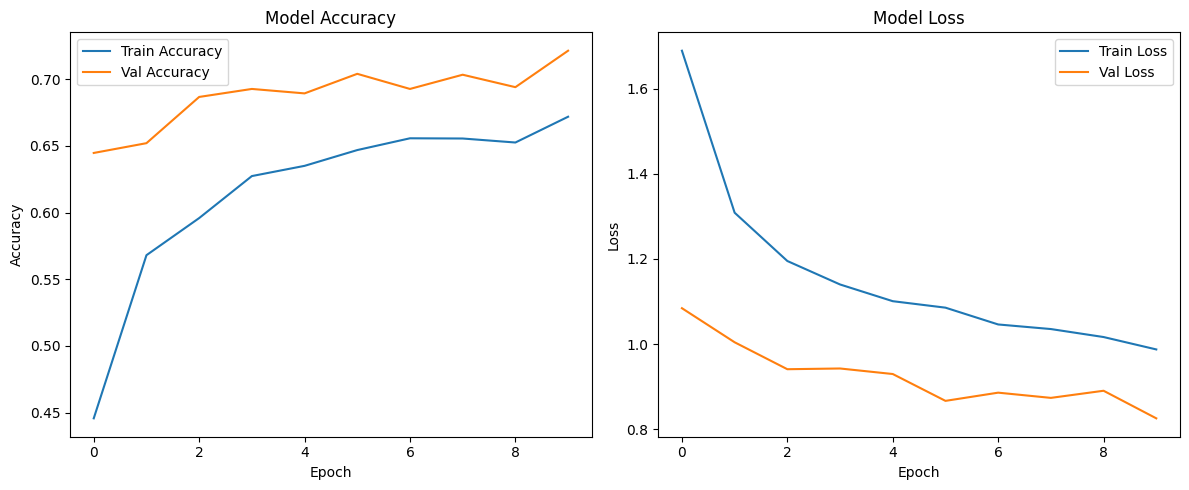

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()